In [44]:
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import platform

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [45]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    'latitude': 37.5665,
    'longitude': 126.9780,
    'start_date': '2025-01-01',
    'end_date': '2025-12-31',
    'hourly': 'temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,rain'
}

res = requests.get(url, params = params)
data = res.json()
data

{'latitude': 37.57469,
 'longitude': 126.96,
 'generationtime_ms': 5.118370056152344,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 34.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'relative_humidity_2m': '%',
  'surface_pressure': 'hPa',
  'wind_speed_10m': 'km/h',
  'rain': 'mm'},
 'hourly': {'time': ['2025-01-01T00:00',
   '2025-01-01T01:00',
   '2025-01-01T02:00',
   '2025-01-01T03:00',
   '2025-01-01T04:00',
   '2025-01-01T05:00',
   '2025-01-01T06:00',
   '2025-01-01T07:00',
   '2025-01-01T08:00',
   '2025-01-01T09:00',
   '2025-01-01T10:00',
   '2025-01-01T11:00',
   '2025-01-01T12:00',
   '2025-01-01T13:00',
   '2025-01-01T14:00',
   '2025-01-01T15:00',
   '2025-01-01T16:00',
   '2025-01-01T17:00',
   '2025-01-01T18:00',
   '2025-01-01T19:00',
   '2025-01-01T20:00',
   '2025-01-01T21:00',
   '2025-01-01T22:00',
   '2025-01-01T23:00',
   '2025-01-02T00:00',
   '2025-01-02T01:00',
   '2025-01-02T02:00',
   '2025

In [46]:
# 날씨 데이터들을 따로 추출

df = pd.DataFrame(data['hourly'])
df.columns = ['측정 시간', '기온', '상대 습도', '지면 기압', '풍속', '강수량']

**연습문제**

1. 날씨 데이터에서 분류할 데이터가 존재하지 않는다.
    - 강수량 데이터를 기준으로 0보다 크다면 1(비), 아니라면 0(맑음) 데이터를 이용하여 target column 생성
    - target data의 분포 확인

2. 측정 시간 column을 시계열 데이터로 변경

3. Dataset을 만들어서 구간을 3일치 데이터(72시간)로 잡는다.

4. DataLoader를 생성, batch = 64, shuffle = False

5. LSTM 정의
    - LSTM은 기본값들을 사용, batch_first = True

6. 모델 생성, 손실 함수, 옵티마이저 구성

7. 반복 학습, epochs = 20
    - 반복마다 loss 값 출력
    - 정확도 출력 (후순위)

8. 학습된 모델을 이용하여 예측



#### **강사님 풀이**

In [47]:
# 파생변수 target 생성

df['target'] = (df['강수량'] > 0).astype(int)
df['target'].value_counts()

target
0    7506
1    1254
Name: count, dtype: int64

In [48]:
x = df[['기온', '상대 습도', '지면 기압', '풍속']].values
y = df['target'].values

In [49]:
# x 스케일링

x_sc = MinMaxScaler().fit_transform(x)

In [50]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = len(_x) - _window
    
    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = self.x[ idx : idx + self.window ]
        y = self.y[ idx + self.window ]
        x_tensor = torch.tensor(x).float()
        y_tensor = torch.tensor(y).long()

        return x_tensor, y_tensor

window = 72
train_ds = windowDS(x_sc, y, window)
train_dl = DataLoader(train_ds, batch_size = 64, shuffle=False)

In [51]:
class LSTMclf(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size
    ):
        super(LSTMclf, self).__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            batch_first = True
        )
        self.model = nn.Linear(hidden_size, 2)
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        # h_n[-1], c_n[-1]: bidirectional이 False인 경우 사용 가능
            # True인 경우 역방향의 아웃풋 피쳐만 불러온다.
        # out: 3차원 데이터셋 → [batch, window, feature]
        # 2차원 데이터셋의 형태로 변경 → out[:, -1, :] → [batch, feature]
        pred = self.model(out[:, -1, :])
        return pred

In [52]:
model = LSTMclf(input_size = x.shape[1], hidden_size=32)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

In [54]:
# 반복 학습 (loss, acc)
model.train()

for epoch in range(20):
    total_loss, total_n = 0.0, 0
    current1 = current2 = 0
    acc_list = []
    
    for x, y in train_dl:
        res = model(x)
        loss = criterion(res, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_n += y.size(0)
        _, pred = torch.max(res, 1)
        acc = accuracy_score(y.numpy(), pred.numpy())
        acc_list.append(acc)

        current1 += (y == pred).sum().item()
    
    train_loss = total_loss / len(train_dl)
    mean_current = (current1 / max(total_n, 1)) * 100
    current2 = np.mean(acc_list)

    print(f'Epoch: {epoch+1}, EntropyLoss: {round(train_loss, 3)}, \
    Acc1: {round(mean_current, 3)}, Acc2: {round(current2, 3)}')

Epoch: 1, EntropyLoss: 0.503,     Acc1: 83.541, Acc2: 0.836
Epoch: 2, EntropyLoss: 0.404,     Acc1: 85.566, Acc2: 0.856
Epoch: 3, EntropyLoss: 0.399,     Acc1: 85.566, Acc2: 0.856
Epoch: 4, EntropyLoss: 0.39,     Acc1: 85.566, Acc2: 0.856
Epoch: 5, EntropyLoss: 0.377,     Acc1: 85.566, Acc2: 0.856
Epoch: 6, EntropyLoss: 0.361,     Acc1: 85.566, Acc2: 0.856
Epoch: 7, EntropyLoss: 0.351,     Acc1: 85.566, Acc2: 0.856
Epoch: 8, EntropyLoss: 0.346,     Acc1: 85.589, Acc2: 0.856
Epoch: 9, EntropyLoss: 0.341,     Acc1: 85.808, Acc2: 0.858
Epoch: 10, EntropyLoss: 0.333,     Acc1: 85.958, Acc2: 0.86
Epoch: 11, EntropyLoss: 0.333,     Acc1: 85.992, Acc2: 0.86
Epoch: 12, EntropyLoss: 0.332,     Acc1: 85.923, Acc2: 0.859
Epoch: 13, EntropyLoss: 0.336,     Acc1: 86.027, Acc2: 0.861
Epoch: 14, EntropyLoss: 0.331,     Acc1: 85.946, Acc2: 0.86
Epoch: 15, EntropyLoss: 0.329,     Acc1: 85.877, Acc2: 0.859
Epoch: 16, EntropyLoss: 0.325,     Acc1: 86.084, Acc2: 0.861
Epoch: 17, EntropyLoss: 0.329,     Ac

In [59]:
# 예측
model.eval()

eval_loader = DataLoader(train_ds, batch_size = 1000, shuffle=False)

# 첫번째 데이터만 로드
x, y = next(iter(eval_loader))

with torch.no_grad():
    test_out = model(x)
    _, test_pred = torch.max(test_out, 1)

In [63]:
if platform.system() == 'Windows':
    plt.rc('font', family = 'Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

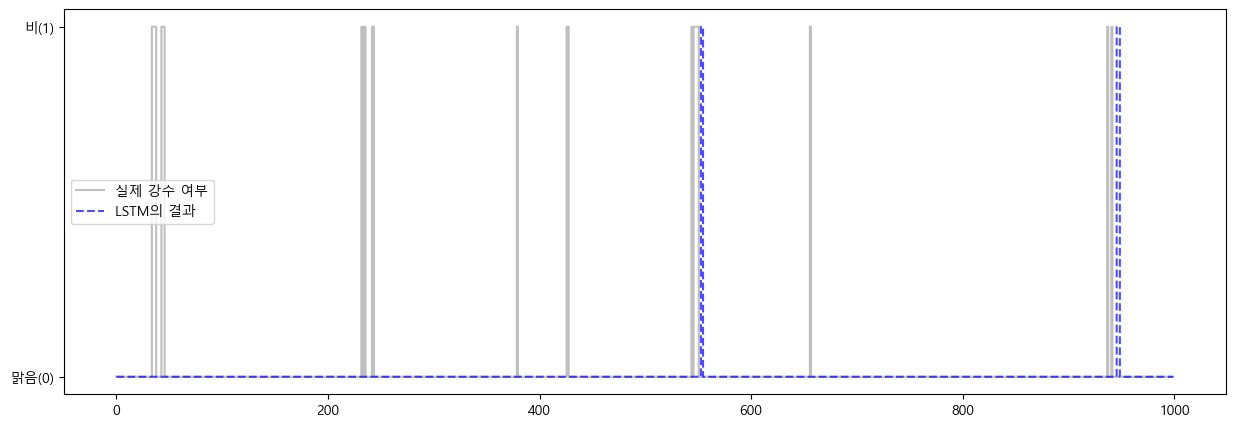

In [70]:
plt.figure(figsize=(15, 5))
plt.plot(y.numpy(), label = '실제 강수 여부', color = 'gray', drawstyle = 'steps-mid', alpha = 0.5)
plt.plot(test_pred.numpy(), label = 'LSTM의 결과', color = 'blue', linestyle = '--', drawstyle = 'steps-mid', alpha=0.7)
plt.yticks([0, 1], ['맑음(0)', '비(1)'])
plt.legend()
plt.show()